# PSI5123 Problem Set

Author: João Victor Colombari Carlet (5274502)

In [90]:
import sys
print(sys.executable)

!{sys.executable} -m pip -q install scipy librosa numpy matplot

/Users/joaovitor/Documents/PhD/aulas_USP/machine_learning_voz/PSI5123_problem_set/venv/bin/python

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### 1. Sketch the waveforms corresponding to the following spectrograms

The spectrogram is a time-frequency plot in which signals are rather easy to be visually identified. 

The signals can be identified by their harmonic content given in the left-hand side y-axis, and their dynamics may change with time, in the x-axis. Accordingly, the signal in question are:

- A 1kHz tone for 5 seconds 

- A 500Hz tone from 0 to 2.5s, followed by a 1kHz tone from 2.5 to 5s

- A 1kHz tone from 0 to 2s, silence from 2 to 3s and then a 500Hz from 3 to 5s

- A linear, single-tone frequency sweep from 0Hz to 2kHz in 5s

- An exponential, single-tone frequency sweep from 0 to 2kHz in 5s

- Four octaves of A from 0 to 5s

The next code block sketches it and the following one plots their spectrogram for checking. In the waveforms, I have changed the time frame for better visualization.

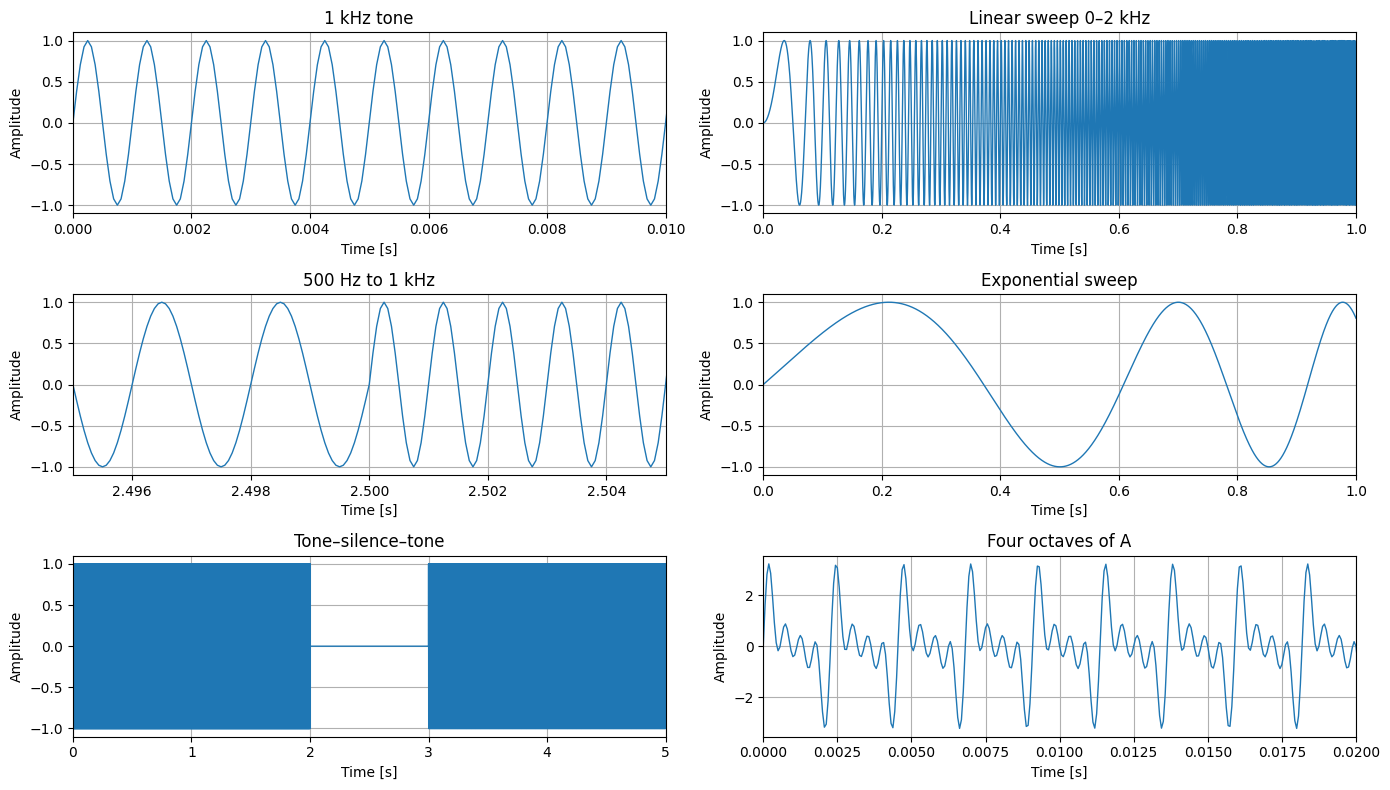

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

fs = 16000 # Just for better resolution. Im cropping the spectrogram then
T = 5
t = np.linspace(0, T, fs*T, endpoint=False)

# -------- Signals --------
x1 = np.sin(2*np.pi*1000*t)

f_lin = np.linspace(0, 2000, len(t))
x2 = np.sin(2*np.pi * f_lin * 0.5 * t)

x3 = np.zeros_like(t)
x3[t < 2.5] = np.sin(2*np.pi*500*t[t < 2.5])
x3[t >= 2.5] = np.sin(2*np.pi*1000*t[t >= 2.5])

f0, f1 = 1, 2000
k = np.log(f1/f0) / T
phase = 2*np.pi * f0 * (np.exp(k*t) - 1) / k
x4 = np.sin(phase)

x5 = np.zeros_like(t)
x5[t < 2] = np.sin(2*np.pi*1000*t[t < 2])
x5[t >= 3] = np.sin(2*np.pi*500*t[t >= 3])

freqs = [440, 880, 1320, 1760]
x6 = sum(np.sin(2*np.pi*f*t) for f in freqs)

signals = [x1, x2, x3, x4, x5, x6]
titles = [
    "1 kHz tone",
    "Linear sweep 0–2 kHz",
    "500 Hz to 1 kHz",
    "Exponential sweep",
    "Tone–silence–tone",
    "Four octaves of A"
]

xlims = [
    (0, 0.01),   # x1
    (0, 1),      # x2
    (2.495, 2.505),      # x3
    (0, 1),      # x4
    (0, 5),      # x5
    (0, 0.02)    # x6
]

fig, axes = plt.subplots(3, 2, figsize=(14, 8))

for ax, x, title, xlim in zip(axes.ravel(), signals, titles, xlims):

    ax.plot(t, x, linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Amplitude")

    ax.set_xlim(xlim)

    ax.grid(True)

plt.tight_layout()
plt.show()


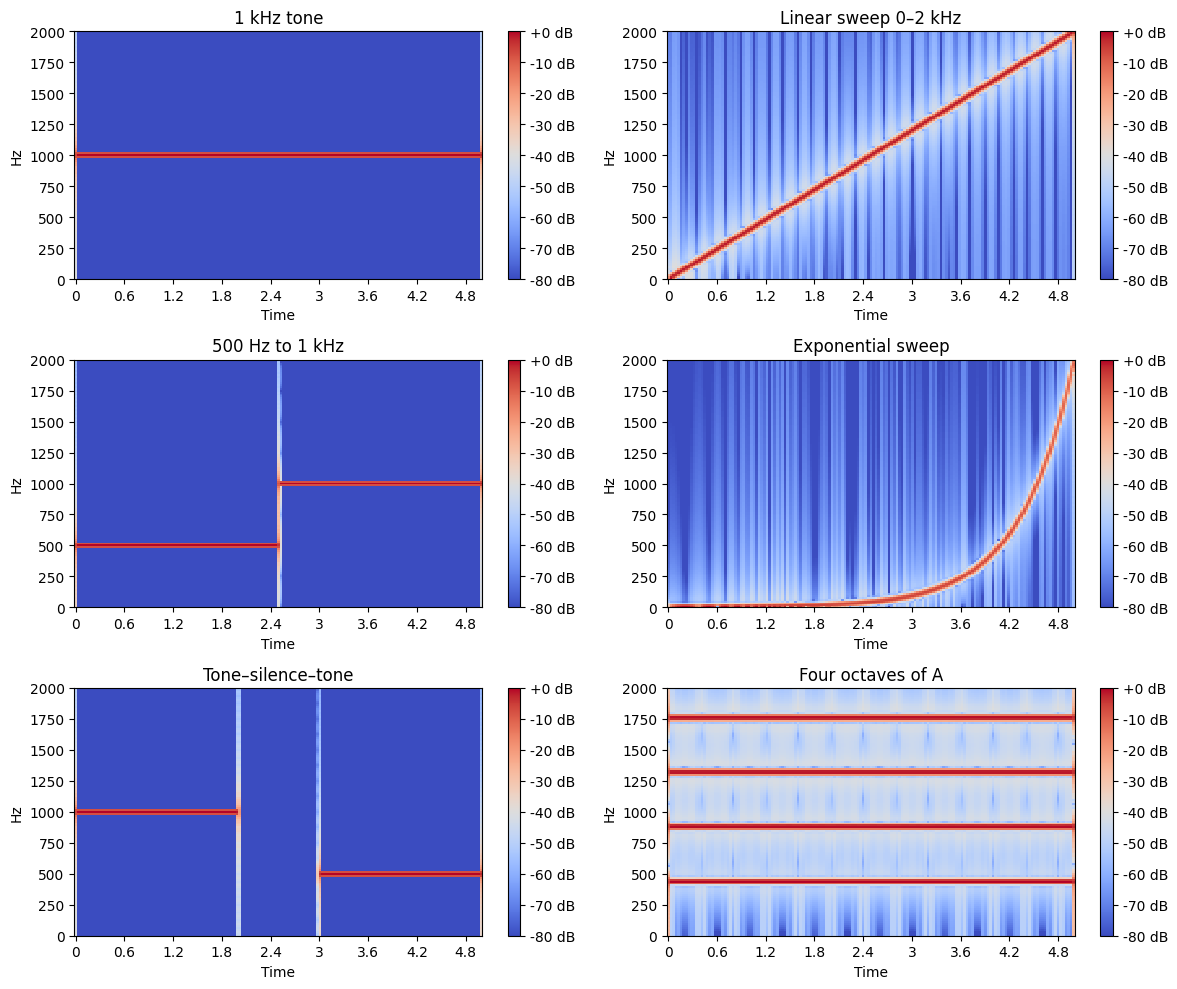

In [92]:
# -------- Spectrogram --------
n_window = 1024
hop_length = 512
n_fft = 1024

# -------- Plot --------
plt.figure(figsize=(12, 10))
for i, (x, title) in enumerate(zip(signals, titles), 1):
    S = librosa.stft(x, win_length=n_window, hop_length=hop_length, n_fft=n_fft, window='hamming')
    S_dB = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    plt.subplot(3, 2, i)
    img = librosa.display.specshow(
        S_dB,
        sr=fs,
        hop_length=hop_length,
        x_axis='time',
        y_axis='hz',
        cmap='coolwarm',   # blue ↔ red
        vmin=-80,
        vmax=0
    )

    plt.ylim(0, 2000)
    plt.title(title)
    plt.colorbar(img, format="%+2.0f dB")

plt.tight_layout()
plt.show()

### 2. Given the spectrogram of a voice signal, determine:

a) What was the sampling frequency used?

<img src="input_figures/f1.png" width="500">

The spectrogram displays frequencies up to **4000 Hz** on the vertical axis.

Assuming this corresponds to the full bandwidth, which appears to be consistent with what is displayied in the figure, the maximum frequency shown is the Nyquist frequency:

$$ f_{max} = f_s / 2 $$

Therefore:

$$ f_s = 2 × 4000 = 8000 Hz $$

**Answer:** The sampling frequency is **8 kHz**, assuming the spectrogram is not frequency-cropped.

b) The following figure shows a zoom of the spectrogram presented in item a). Calculate the frequency resolution and the window length in number of samples. Consider, for this case, that the window size is equal to the number of samples used for the FFT.

<img src="input_figures/f2.png" width="500">

The frequency resolution of the DFT is determined by the duration of the analyzed signal:

$$\Delta f = \frac{f_s}{N} = 1/T_d, $$

where $T_d$ is the window duration in seconds. 

The zoomed figure evidently shows a resolution $\Delta f$ of 10Hz, therefore:

$$ 10 = \frac{8000}{N} \rightarrow N = 800 $$

c) Still regarding the spectrogram zoom, estimate the temporal resolution and calculate the value of the distance between segments/hop size in number of samples.

The window duration $T_d$ is 

$$ \frac{1}{T_d} = \Delta f \rightarrow T_d = \frac{1}{10} = 0.1s $$

Since each time step is equivalent to 0.05s in the spectrogram, it can be concluded that there is 50\% overlap in each window, therefore the hop size in number of samples is equal to $N/2 = 400$ samples.

### 3 - The following waveform presents the statement "A profissão de aeromoça" (the profession of flight assistent) sampled with fs = 16000Hz. Segment the waveform into regions of voiced sounds (V), voiceless/unvoiced sounds (N) and silence (S).

This description follows the classical speech production model presented in the book *Digital Processing of Speech Signals* by Rabiner, Lawrence, and Ronald Schafer. Theory and applications of digital speech processing. Prentice Hall Press, 2010.

Speech production involves multiple anatomical structures. The **vocal tract** extends from the glottis to the lips, while the **nasal tract** extends from the velum to the nostrils. In addition, the lungs and thoracic cavity play a fundamental role in generating airflow.

#### Voiced sounds (V)

Voiced sounds, including most vowels, are produced through a quasi-periodic excitation mechanism:

1. Air is drawn into the lungs.  
2. Air is expelled through the trachea, causing the vocal folds to vibrate under tension.  
3. The airflow is modulated by the opening and closing of the glottis, generating quasi-periodic pulses.  
4. These pulses are shaped in frequency by the vocal tract resonances and articulators.

The vibration mechanism arises from the interaction between muscular tension (which tends to close the vocal folds) and aerodynamic pressure (which forces them open). This cyclic process produces a quasi-periodic signal characteristic of voiced speech. There is also a slight delay between pressure buildup and sound radiation.

#### Unvoiced sounds (N)

Unvoiced (or voiceless) sounds occur when the vocal fold constriction is reduced, allowing airflow without periodic vibration. These sounds are generated by turbulence caused by constrictions in the vocal tract, particularly in the oral cavity (e.g., lips and teeth).

As a result, unvoiced sounds resemble noise-like signals (e.g., the /s/ sound in “see”).

#### Silence (S)

Silence corresponds to segments where neither voiced nor unvoiced excitation is present. These regions occur:

- Between utterances  
- Between phonemes within speech  

In practice, unvoiced regions can be difficult to distinguish from background noise, and silence is often defined as the absence of both voiced and unvoiced activity.

An illustrative example of these regions can be observed in the following figure:

<img src="input_figures/f3.png" width="500">

For annotation purposes, I adopted a simplified phoneme labeling using a one-to-one correspondence between letters and symbols (i.e., /letter/). This approach is not rigorous, but it is sufficient to guide the segmentation of voiced (V), unvoiced (N), and silence (S) regions.

A specific case occurs in the final syllable of *“aeromoça”* (“-ça”). In natural speech, the final vowel /a/ is often **reduced or devoiced**, especially in unstressed position. 

To reflect this behavior, I annotated it as **/ç(A)/**, indicating that the vowel is present at a phonological level but is **partially suppressed** in the acoustic signal.

<img src="input_figures/f4.png" width="500">

### 4 – Comparison of two methods for estimating the fundamental frequency, F0: the autocorrelation function and the Simplified Inverse Filter Tracking (SIFT) algorithm.

For the autocorrelation method, considering a segment of \(N\) samples of a voice signal, \(s[n]\), its autocorrelation function, \(R[m]\), can be calculated by:

$$
R[m] = \sum_{n=0}^{N-1-m} s[n]\,s[n+m],
$$

for m=0,1,...,N-1. The main peak in the autocorrelation function is at m = 0, the location of the zero lag. The distance between the first maximum and the second maximum represents the period (lag) and, consequently, dividing the sampling frequency value by the lag gives an estimate of the value of F0.

For the SIFT method, the algorithm initially performs a resampling of the voice signal to 2 kHz. Then, a linear prediction analysis (LPC) is applied to model the vocal tract, obtaining the coefficients of the predictive filter. The voice signal segment is then filtered by the inverse model, resulting in the residual signal, which represents an estimate of the glottal excitation. On this residual signal, the autocorrelation function is calculated, analogously to the previous method.

<img src="input_figures/f5.png" width="500">

#### a) Open the monophonic file SA1.WAV using the librosa library with a sampling frequency of 2 kHz. Implement a function that segments the file into 32 ms blocks with a 16 ms overlap. Plot the waveform.

Signal length: 5850 samples
Frame size: 64 samples
Hop: 32 samples
Number of Frames: 183


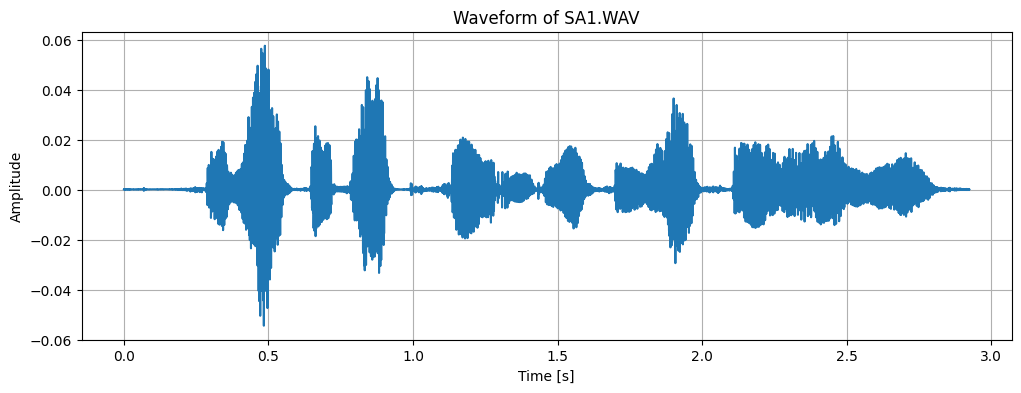


Manual segmentation shape:
(64, 183)

Librosa segmentation shape:
(64, 183)

Maximum difference between methods: 0.0


In [93]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# -------- Load Audio File --------

# O primeiro pico eu vou falar que é o primeiro lag e vou usar para achar a função de autocorrelação
# Nesse eu tenho que implementar a segmentação na unha. Da pra comparar com a função da librosa que 
# usa na aula 4 de segmentação..
# Tem que aplicar o padding manualmente nesse caso pq ela não aplica!

# # Usar a função de enquadramento do librosa

# x_had_pad = np.pad(x_had, (frame_length//2, frame_length//2), 'constant', constant_values=(0,0))

# frames = librosa.util.frame(x_had_pad, frame_length=frame_length, hop_length=hop_length)
# print(f"\nResultado da segmentação (formato librosa):\n{frames}") # com zero pading centralizado 

# # No librosa, cada coluna é um quadro. Para obter os quadros como linhas, transponha.
# print(f"\nResultado dda segmentação (quadros como linhas):\n{frames.T}")

fs = 2000  
signal, sr = librosa.load("SA1.WAV", sr=fs, mono=True)

# -------- Segmentation  --------

frame_duration_ms = 32
hop_duration_ms = 16

frame_size = int(fs * frame_duration_ms / 1000)     # 32 * 1e-3 * 2e3 = 64 samples
hop_size = int(fs * hop_duration_ms / 1000) # 32 samples

signal_pad = np.pad(signal, (frame_size//2, frame_size//2), 'constant', constant_values=(0,0)) # Centered zero padding

def manual_segment_signal(x, frame_size, hop_size):
    
    num_frames = 1 + (len(x) - frame_size) // hop_size

    frames = np.zeros((num_frames, frame_size))

    for i in range(num_frames):
        start = i * hop_size
        end = start + frame_size
        frames[i, :] = x[start:end]

    # Reshape to match librosa format:
    # (frame_length, num_frames)
    frames = frames.T

    return frames

frames = manual_segment_signal(signal_pad, frame_size, hop_size)

print(f"Signal length: {len(signal)} samples")
print(f"Frame size: {frame_size} samples")
print(f"Hop: {hop_size} samples")
print(f"Number of Frames: {frames.shape[1]}")

# -------- Plot  --------

time = np.arange(len(signal)) / fs

plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Waveform of SA1.WAV")
plt.grid(True)
plt.show()

# -------- Librosa Segmentation --------

frames_librosa = librosa.util.frame(
    signal_pad,
    frame_length=frame_size,
    hop_length=hop_size
)

print("\nManual segmentation shape:")
print(frames.shape)

print("\nLibrosa segmentation shape:")
print(frames_librosa.shape)

# Check difference
difference = np.max(np.abs(frames - frames_librosa))

print(f"\nMaximum difference between methods: {difference}")

#### b) Implement the autocorrelation algorithm, limiting F0 between 40 and 400 Hz. For each segment, calculate the energy and, if it exceeds a previously defined threshold, proceed with the estimation of the fundamental frequency, F0.

For consistency, I'm calculating everything for the frame starting at 480ms as given in class.

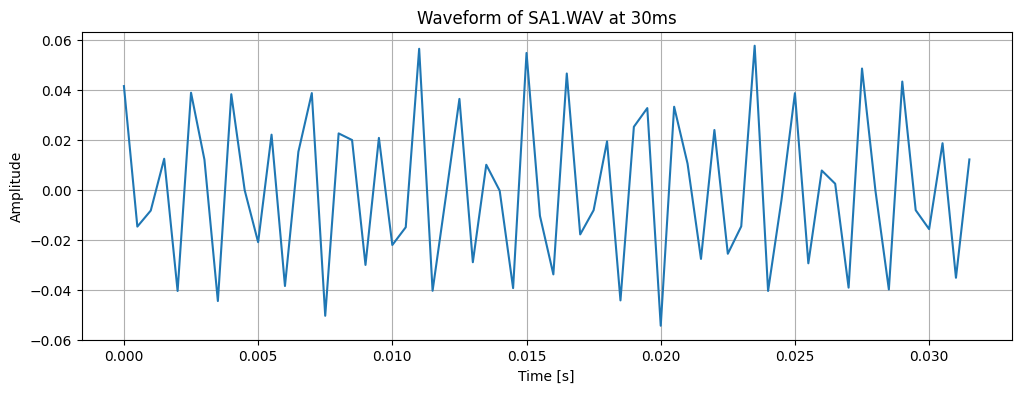

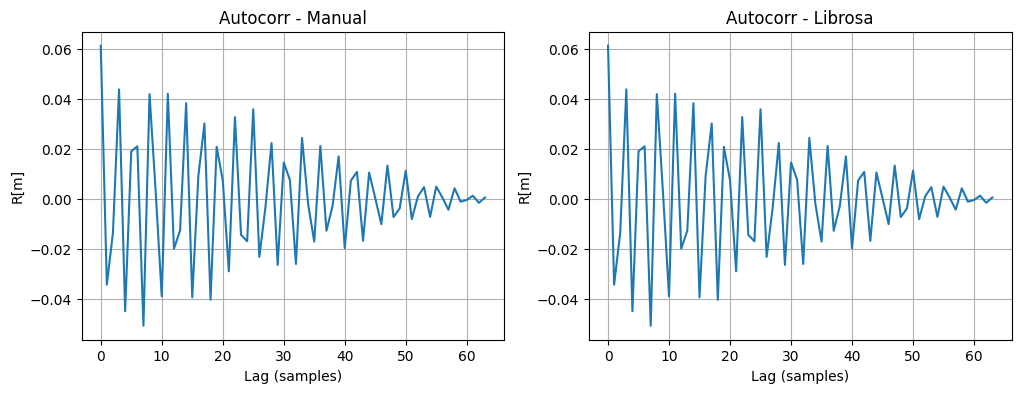

In [94]:
# Selecting the same voiced section used in the lecture
frame_index = int(480/hop_duration_ms)  # Index at t=48ms -> .48 / .016 = 30
signal = frames[:, frame_index]
N = len(signal) 

time = np.arange(N) / sr

plt.figure(figsize=(12, 4))
plt.plot(time, signal)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Waveform of SA1.WAV at 30ms")
plt.grid(True)
plt.show()

# -------- Manual Autocorr -------- 

R = np.zeros(N)                 ## like shown in class!
for m in range(N):
    for n in range(N - m):
        R[m] += signal[n] * signal[n + m]

# -------- Librosa Autocorr -------- 
R_lib = librosa.autocorrelate(signal)

# -------- Plotting -------- 
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(R)
plt.title('Autocorr - Manual')
plt.xlabel('Lag (samples)')
plt.ylabel('R[m]')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(R_lib)
plt.title('Autocorr - Librosa')
plt.xlabel('Lag (samples)')
plt.ylabel('R[m]')
plt.grid(True)
plt.show()

Valid lag interval: 5 to 50 samples
Peaks indexes: [ 6  8 11 14 17 19 22 25 28 30 33 36 39 42 44 47]
Estimated lag: 11 samples
Estimated fundamental frequency (F0): 181.82 Hz


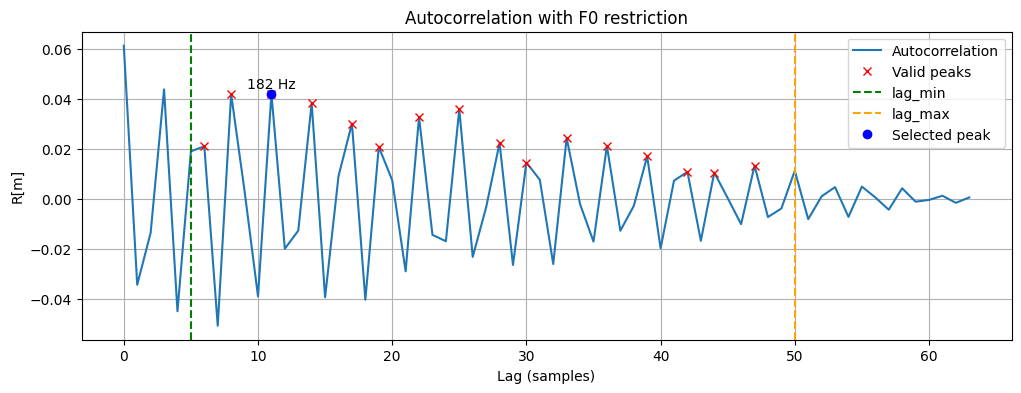

In [95]:
# -------- F0 restriction --------

f0_min = 40
f0_max = 400

lag_min = int(sr / f0_max)
lag_max = int(sr / f0_min)

print(f"Valid lag interval: {lag_min} to {lag_max} samples")

# -------- Finding peaks only inside valid region --------

from scipy.signal import find_peaks

R_valid = R[lag_min:lag_max]
peaks, _ = find_peaks(R_valid, height=0)
peaks = peaks + lag_min

print(f"Peaks indexes: {peaks}")

# -------- Best peak --------

best_peak = peaks[np.argmax(R[peaks])]

f0 = sr / best_peak

print(f"Estimated lag: {best_peak} samples")
print(f"Estimated fundamental frequency (F0): {f0:.2f} Hz")

# -------- Plotting --------

plt.figure(figsize=(12, 4))

plt.plot(R, label='Autocorrelation')
plt.plot(peaks, R[peaks], 'rx', label='Valid peaks')

plt.axvline(lag_min, color='g', linestyle='--', label='lag_min')
plt.axvline(lag_max, color='orange', linestyle='--', label='lag_max')

plt.plot(best_peak, R[best_peak], 'bo', label='Selected peak')
plt.text(best_peak, R[best_peak] + 0.002, f"{sr/best_peak:.0f} Hz", ha='center')

plt.title('Autocorrelation with F0 restriction')
plt.xlabel('Lag (samples)')
plt.ylabel('R[m]')

plt.legend()
plt.grid(True)
plt.show()

##### Discussion

At fs = 2 kHz, lag resolution becomes coarse. A difference of 1 sample changes the F0 estimate significantly, which makes neighboring peaks produce noticeably different F0 values. In addition, the 32 ms window contains only 64 samples, which limits pitch resolution and increases ambiguity.

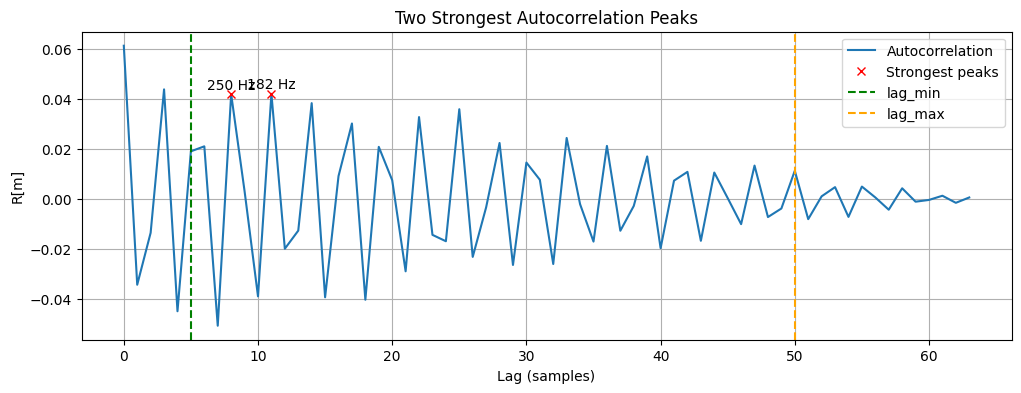

In [96]:
# Sort peaks by autocorrelation amplitude
sorted_peaks = peaks[np.argsort(R[peaks])[::-1]]
top_peaks = sorted_peaks[:2]

# -------- Plotting --------

plt.figure(figsize=(12,4))
plt.plot(R, label='Autocorrelation')
plt.plot(top_peaks, R[top_peaks], 'rx', label='Strongest peaks')
plt.text(top_peaks[0], R[top_peaks[0]] + 0.002, f"{sr/top_peaks[0]:.0f} Hz", ha='center')
plt.text(top_peaks[1], R[top_peaks[1]] + 0.002, f"{sr/top_peaks[1]:.0f} Hz", ha='center')

# Valid lag interval
plt.axvline(lag_min, color='g', linestyle='--', label='lag_min')
plt.axvline(lag_max, color='orange', linestyle='--', label='lag_max')
plt.xlabel("Lag (samples)")
plt.ylabel("R[m]")
plt.title("Two Strongest Autocorrelation Peaks")
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

On the other hand, if the frequency is set back to 16kHz as done in class, resolution increases and the fundamental returns to around 250Hz dispite the distinct hop and frame sizes:

<img src="input_figures/f6.png">

#### c) Implement the SIFT algorithm, consider testing the linear prediction with an order equal to 4. Limit F0 between 40 and 400 Hz and discard the last two blocks of the SIFT diagram. For each segment, calculate the energy and, if it exceeds a previously defined threshold, proceed with the estimation of the fundamental frequency, F0.

The algorithm is proposed in *The SIFT algorithm for fundamental frequency estimation* by John Markel. IEEE Transactions on Audio and Electroacoustics 20.5 (2003): 367-377. In the paper, the same frame and hop sizes, as well as sampling frequency previously used in this exercise were selected. Markel's procedure is done by:

##### 1. Pre-processing (Filtering & Decimation)
To reduce computational complexity and focus on the fundamental frequency range, the input signal is:
- **Low-pass filtered**: Using a filter with a cutoff frequency around 800 Hz.
- **Downsampled**: Decimated to a sampling rate of 2 kHz. 

The signal is already at 2kHz, therefore from the pre-processing block the filter is the only thing to be implemented.

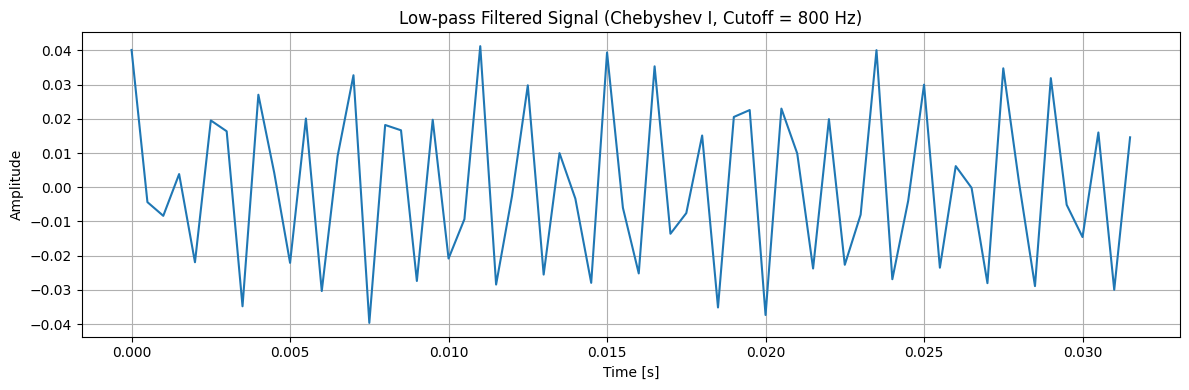

In [97]:
import scipy.signal as sn

# SIFT Parameters according to the original paper
lpc_order = 4
f_cutoff = 800  # Cutoff frequency as specified by Markel
fs = 2000       # Sampling rate (already decimated to 2kHz)

# Markel uses a 3rd-order Chebyshev filter with 2dB ripple
nyquist = fs / 2
# Normalizing the cutoff frequency and calculating the filter 
b_lp, a_lp = sn.cheby1(3, 2, f_cutoff / nyquist, btype='low')

# Apply the filter to the frame 
signal_filtered = sn.filtfilt(b_lp, a_lp, signal)

# -------- Plotting -------- 
plt.figure(figsize=(12, 4))
plt.plot(time, signal_filtered)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title(f"Low-pass Filtered Signal (Chebyshev I, Cutoff = {f_cutoff} Hz)")
plt.grid(True)

plt.tight_layout()
plt.show()

##### 2. Inverse Filter Estimation (LPC)
The spectral envelope (formants) is estimated using **Linear Predictive Coding (LPC)**.
- A 4th-order inverse filter $A(z)$ is calculated by solving for the inverse filter coeficients {${a_i}$}

Librosa does this calculation with .lpc: 

In [98]:
# --- STEP 2: LPC Analysis (Order 4) ---
# Estimate the vocal tract filter coefficients
a_lpc = librosa.lpc(signal_filtered, order=lpc_order)

##### 3. Residual Signal Generation
The decimated signal is passed through the inverse filter $A(z)$. This process, known as "whitening," removes the resonances of the vocal tract. The resulting **residual signal** (or prediction error) consists primarily of periodic spikes corresponding to the glottal closures.

I.e., knowing {${a_i}$}, the inverse filter output {${y_n}$} can be calculated:

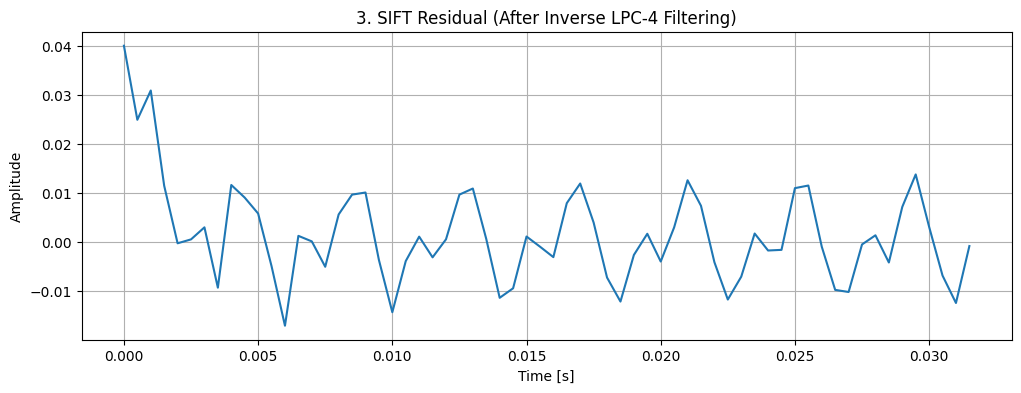

In [99]:
# --- STEP 3: Inverse Filtering (Residual Generation) ---
# The residual signal represents the glottal excitation
residual = sn.lfilter(a_lpc, [1], signal_filtered)

plt.figure(figsize=(12, 4))
plt.plot(time, residual)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("3. SIFT Residual (After Inverse LPC-4 Filtering)")
plt.grid(True)
plt.show()

##### 4. Short-term Autocorrelation

The output autocorrelation sequence {${r_n}$} from which Fo is estimated is then calculated as the autocorrelation sequence of {${y_n}$}

- Because the formants have been removed, the autocorrelation function exhibits much sharper peaks at the pitch period ($P$) compared to the autocorrelation of the original speech signal.

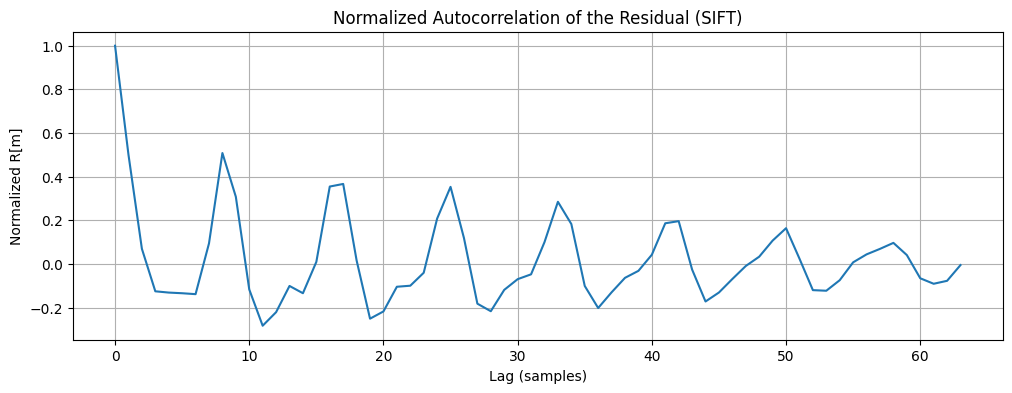

In [100]:
# --- STEP 4: Autocorrelation of the Residue ---
# I'll use the 'residual' variable calculated in Step 3.
r_residue = librosa.autocorrelate(residual)

# Normalization: R[m] / R[0]
r_residue = r_residue / r_residue[0]

# -------- Plotting the Residual Autocorrelation --------
plt.figure(figsize=(12, 4))
plt.plot(r_residue)
plt.title('Normalized Autocorrelation of the Residual (SIFT)')
plt.xlabel('Lag (samples)')
plt.ylabel('Normalized R[m]')
plt.grid(True)
plt.show()

##### 5. Peak Picking and F0 Estimation

In this final stage, the first maximum peak within the range is once again searched. According to the problem statement, we should also check the segment energy before estimation. I know that the first few frames are silcence by the waveform, therefore I will use it as a reference for silence. 

For estimating between voiced and unvoiced, Markel uses a normalized $R_{xx}$ of 0.4. Similarlly, I chose to use the Itakura-Saito thresholds for Voiced and Unvoiced sounds: 

<img src="input_figures/f7.png" width="500">

Therefore I will peak 1/4 as the threshold for voiced sounds, as no sound is classified as Unvoiced above it.

--- SIFT Results for Frame 30 ---
Frame Energy: -30.20 dB
Energy Threshold: -73.11 dB
Residual Peak: 0.508
Estimated Lag: 8 samples
Estimated F0: 250.00 Hz


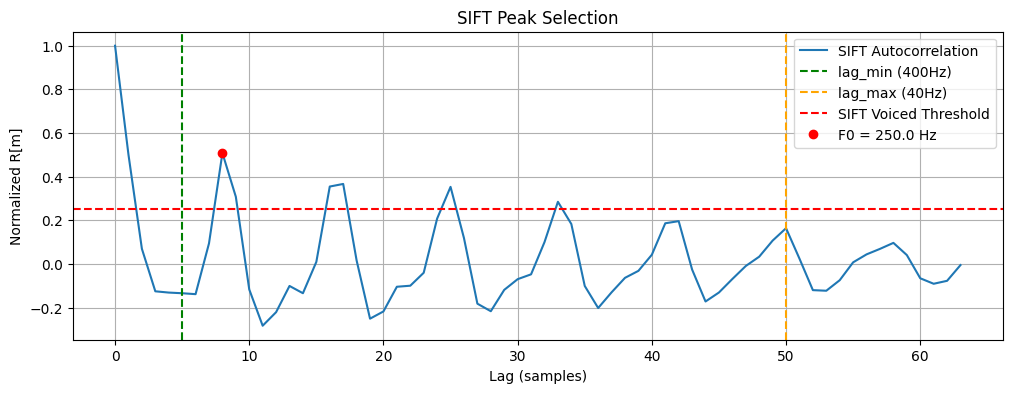

In [101]:
# --- STEP 5: F0 Extraction and Decision ---

# -------- Energy threshold from first frame --------
# Assuming frame 0 is silence/noise
noise_frame = frames[:, 0]

# RMS energy of the first frame
noise_energy = np.sqrt(np.mean(noise_frame**2))

# Convert to dB
noise_energy_db = 20 * np.log10(noise_energy + 1e-12)

# Threshold = noise floor + 10 dB
energy_threshold_db = noise_energy_db + 10

# -------- Current frame energy --------
frame_energy = np.sqrt(np.mean(signal**2))
frame_energy_db = 20 * np.log10(frame_energy + 1e-12)

# -------- Voiced/Unvoiced Threshold --------
voiced_threshold = 0.25

# -------- Energy decision -------
if frame_energy_db > energy_threshold_db:
    # 2. Define valid lag range for fs = 2000 Hz
    lag_min = int(fs / f0_max) # 2000 / 400 = 5 samples
    lag_max = int(fs / f0_min) # 2000 / 40 = 50 samples

    # 3. Search for the peak in the residual autocorrelation
    r_valid = r_residue[lag_min:lag_max]

    # Find all peaks in the valid range
    peaks_sift, _ = find_peaks(r_valid, height=0)

    # Local → global lag
    peaks_sift = peaks_sift + lag_min

    if len(peaks_sift) > 0:
        # Select strongest peak
        best_peak_sift = peaks_sift[np.argmax(r_residue[peaks_sift])]
        peak_value = r_residue[best_peak_sift]

        # -------- Voiced decision --------
        if peak_value > voiced_threshold:
            f0_sift = fs / best_peak_sift

            print(f"--- SIFT Results for Frame {frame_index} ---")
            print(f"Frame Energy: {frame_energy_db:.2f} dB")
            print(f"Energy Threshold: {energy_threshold_db:.2f} dB")
            print(f"Residual Peak: {peak_value:.3f}")
            print(f"Estimated Lag: {best_peak_sift} samples")
            print(f"Estimated F0: {f0_sift:.2f} Hz")
        else:
            f0_sift = 0
            print("Residual peak below SIFT threshold (Unvoiced).")
    else:
        f0_sift = 0
        print("Voiced peak not found (Unvoiced).")

else:
    f0_sift = 0
    print("Energy below threshold (Silence/Unvoiced).")

# -------- Plotting --------
plt.figure(figsize=(12, 4))
plt.plot(r_residue, label='SIFT Autocorrelation' )

plt.axvline(lag_min, color='g', linestyle='--', label='lag_min (400Hz)')
plt.axvline(lag_max, color='orange', linestyle='--', label='lag_max (40Hz)')
plt.axhline(voiced_threshold, color='red', linestyle='--', label='SIFT Voiced Threshold')

if f0_sift > 0:
    plt.plot(best_peak_sift, r_residue[best_peak_sift], 'ro', label=f'F0 = {f0_sift:.1f} Hz')

plt.title('SIFT Peak Selection')
plt.xlabel('Lag (samples)')
plt.ylabel('Normalized R[m]')
plt.legend()
plt.grid(True)
plt.show()

#### d) Compare the results by plotting the outputs from the two previous items in superposition.

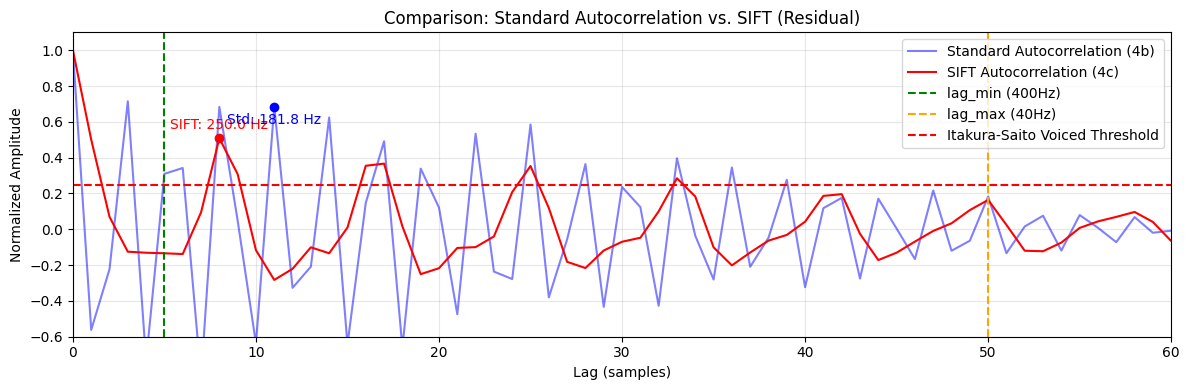

In [103]:
# --- d) Comparison between Standard Autocorrelation and SIFT ---

# 1. Normalize the Standard Autocorrelation (Item 4b)
R_std_norm = R_lib / R_lib[0]

# 2. Normalize the SIFT Residual Autocorrelation (Item 4c)
R_sift_norm = r_residue / r_residue[0]

# -------- Plotting -------- 
plt.figure(figsize=(12, 4))

plt.plot(R_std_norm, label='Standard Autocorrelation (4b)', color='blue', alpha=0.5)
plt.plot(R_sift_norm, label='SIFT Autocorrelation (4c)', color='red', linewidth=1.5)

plt.axvline(lag_min, color='g', linestyle='--', label=f'lag_min ({f0_max}Hz)')
plt.axvline(lag_max, color='orange', linestyle='--', label=f'lag_max ({f0_min}Hz)')
plt.axhline(voiced_threshold, color='red', linestyle='--', label='Itakura-Saito Voiced Threshold')

# -------- Marking Peaks -------- 
if 'best_peak_sift' in locals():
    plt.plot(best_peak_sift, R_sift_norm[best_peak_sift], 'ro')
    plt.text(best_peak_sift, R_sift_norm[best_peak_sift] + 0.05, f"SIFT: {fs/best_peak_sift:.1f} Hz", color='red', ha='center')
if 'best_peak' in locals():
    plt.plot(best_peak, R_std_norm[best_peak], 'bo')
    plt.text(best_peak, R_std_norm[best_peak] - 0.1, f"Std: {fs/best_peak:.1f} Hz", color='blue', ha='center')

plt.title('Comparison: Standard Autocorrelation vs. SIFT (Residual)')
plt.xlabel('Lag (samples)')
plt.ylabel('Normalized Amplitude')
plt.xlim(0, lag_max + 10)
plt.ylim(-0.6, 1.1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Analysis of the Comparison

**Peak Sharpening:** The SIFT curve has much narrower peaks. This is the result of the "whitening" process (inverse filtering). By removing the formants, we reduce the "smearing" effect that the vocal tract resonances have on the autocorrelation function.

**Harmonic Suppression:** Standard autocorrelation often shows broad "humps" due to the first formant. SIFT flattens these humps, making the true pitch much easier to detect automatically without confusion from spectral peaks.

**Efficiency:** Keeping fs at 2 kHz, the standard autocorrelation method proved unreliable as it struggled to distinguish between consecutive peaks of similar amplitude and led a wrong pitch. In contrast, the SIFT method was immune to this ambiguity, consistently yielding the correct pitch estimation.

##### Why I chose to analyse in a single frame

As I pointed, the choice is motivated by the class in which the same signal was analysed. This allowed me to verify my answers and also compare the effect of a reduced sampling frequency, as pointed. Nevertheless, applying the calculations for the whole signal can be easily done by iterating over **frames**. For this, I implemented everything as before in a for loop over frames and plotted only those F0 estimates where the first lag exceeds the 1/4 energy threshold. I will leave it commented.

In [104]:
# # -------- Full-signal SIFT estimation --------
# f0_track = []
# time_track = []

# for i in range(frames.shape[1]):
#     frame = frames[:, i]

#     # -------- Frame energy --------
#     frame_energy = np.sqrt(np.mean(frame**2))
#     frame_energy_db = 20 * np.log10(frame_energy + 1e-12)

#     # -------- Energy gate --------
#     if frame_energy_db <= energy_threshold_db:
#         f0_track.append(0)
#         time_track.append(i * hop_size / fs)
#         continue

#     # -------- 1 - Low-pass filtering --------
#     frame_filtered = sn.lfilter(b_lp, a_lp, frame)

#     # -------- 2 - LPC --------
#     a_lpc = librosa.lpc(frame_filtered, order=lpc_order)

#     # -------- 3 - Residual generation --------
#     residual = sn.lfilter(a_lpc, [1], frame_filtered)

#     # -------- 4 - Residual autocorrelation --------
#     r_residue = librosa.autocorrelate(residual)

#     # Avoid division by zero
#     if r_residue[0] == 0:
#         f0_track.append(0)
#         time_track.append(i * hop_size / fs)
#         continue

#     # -------- Normalization --------
#     r_residue = (r_residue / r_residue[0])

#     # -------- 5 - Peak Picking --------
#     r_valid = r_residue[lag_min:lag_max]

#     # -------- Peak detection --------
#     peaks_sift, _ = find_peaks(r_valid)
    
#     # Local → global lag
#     peaks_sift = (peaks_sift + lag_min)

#     # -------- Peak selection --------
#     if len(peaks_sift) > 0:
#         best_peak_sift = peaks_sift[np.argmax(r_residue[peaks_sift])]
#         peak_value = r_residue[best_peak_sift]

#         # -------- SIFT voiced decision --------
#         if peak_value > voiced_threshold:
#             f0_sift = (fs / best_peak_sift)

#         else:
#             f0_sift = 0

#     else:
#         f0_sift = 0

#     # -------- Store results --------
#     f0_track.append(f0_sift)
#     time_track.append(i * hop_size / fs)

# # -------- Plotting --------
# plt.figure(figsize=(12,4))
# plt.plot(time_track, f0_track)
# plt.xlabel("Time [s]")
# plt.ylabel("Estimated F0 [Hz]")
# plt.title("Full-Signal SIFT F0 Estimation - Voiced Only!")
# plt.grid(True)
# plt.show()

### 5 - For each of the functions below, indicate, justifying your answer, whether it can be an autocorrelation function.

From the exposition by professor Ramírez during the 5th classs, the Autocorrelation Function $R_{xx}(m)$ must have three characteristics:

- Its peak must be at zero, or $|R_{xx}(m)| \leq R_{xx}(0)$

- It must be an even funcion, or $R_{xx}(m)=R_{xx}(-m)$, and

- Its value at zero must be non-negative, or $R_{xx}(0)\geq 0$

For each letter, the function will be displayed continuously for better visualization dispite the dommain of m.

#### a)

$
f_1(m)=
\begin{cases}
\dfrac{M-|m|}{M}, & \text{for } m \leq M \\
0, & \text{for } m > M
\end{cases}
$

Here, clearly $R_{xx}(m)=R_{xx}(-m)$ because of the modulus applied at m. Moreover, the function has its peak at $m=0$ and decays simetrically around this point. 

Therefore, **$f_1(m)$ can be an Autocorrelation Function**

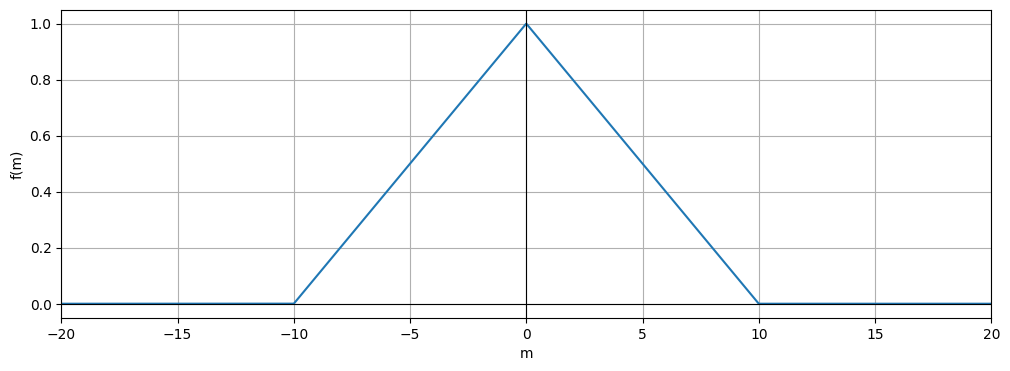

In [105]:
m = np.linspace(-20, 20, 4000)

# -------- a) -------- 

M = 10

f1 = np.where(np.abs(m) <= M, (M - np.abs(m))/M, 0)

plt.figure(figsize=(12,4))
plt.plot(m, f1)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlim([-20, 20])
plt.xlabel("m")
plt.ylabel("f(m)")
plt.xlabel("m")
plt.grid(True)
plt.show()

#### b) 

$
f_2(m)=
\begin{cases}
\dfrac{M-|m-1|}{M}, & \text{for } m \leq M \\
0, & \text{for } m > M
\end{cases}
$

Here, clearly $R_{xx}(m)\neq R_{xx}(-m)$ because of the subtraction within the modulus operator. 

Therefore, **$f_1(m)$ cannot be an Autocorrelation Function**

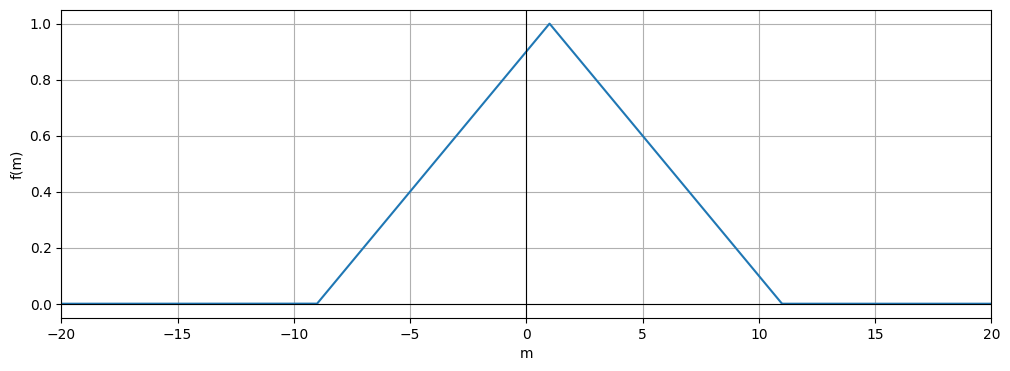

In [106]:
# -------- b) --------

M = 10

f2 = np.where(np.abs(m-1) <= M, (M - np.abs(m-1))/M, 0) # aqui ela anda pra direita e vira impar..

plt.figure(figsize=(12,4))
plt.plot(m, f2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlim([-20, 20])
plt.xlabel("m")
plt.ylabel("f(m)")
plt.xlabel("m")
plt.grid(True)
plt.show()

### c) 

$
f_3(m)=2\cos(2m), \qquad \text{for } m \in \mathbb{Z}
$

$f_3(m)$ is a cossine function, that **can be an Autocorrelation Function** since $f_3(m)=2\cos(2m) = f_3(m)=2\cos(-2m)$, $f_3(m)=2\cos(0) = 2$, value that repeats every period.

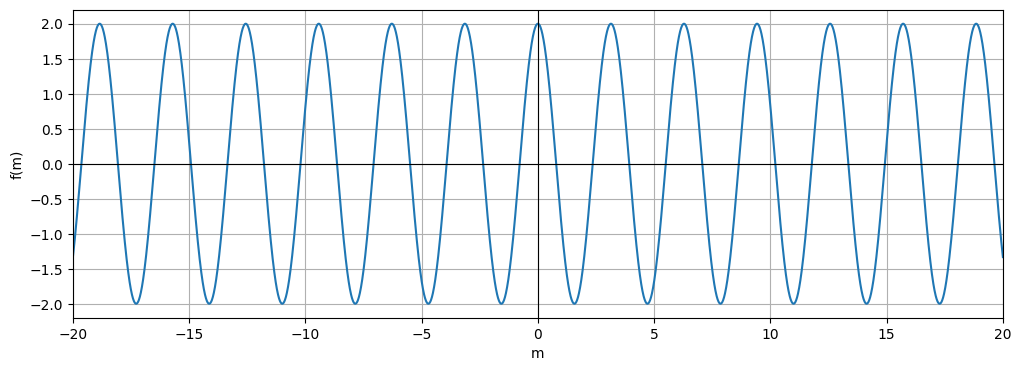

In [107]:
f3 = 2*np.cos(2*m)

plt.figure(figsize=(12,4))
plt.plot(m, f3)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlim([-20, 20])
plt.xlabel("m")
plt.ylabel("f(m)")
plt.xlabel("m")
plt.grid(True)
plt.show()

#### d)

$
f_4(m)=2\sin(2m), \qquad \text{for } m \in \mathbb{Z}
$

The sine is an odd function, and thus **$f_4(m)$ cannot be an Autocorrelation Function**

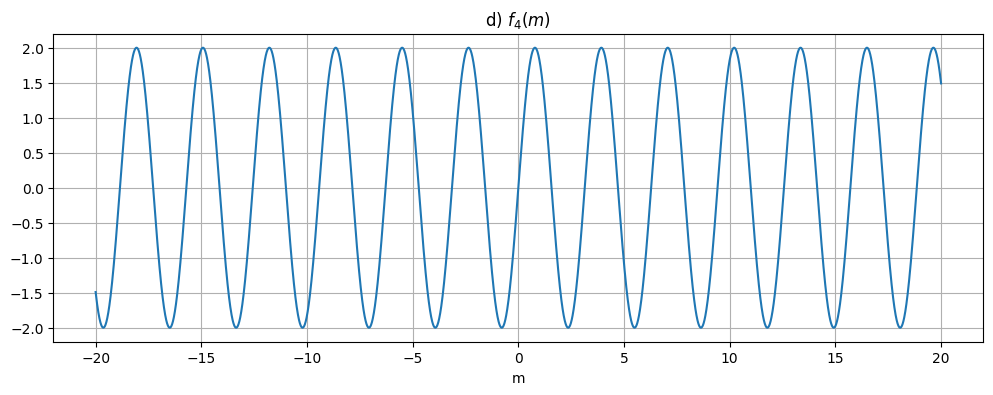

In [108]:
f4 = 2*np.sin(2*m)

plt.figure(figsize=(12,4))
plt.plot(m, f4)
plt.title("d) $f_4(m)$")
plt.xlabel("m")
plt.grid(True)
plt.show()

#### e) 

$
f_5(m)=3e^{-2|m|}\cos(3m), \qquad \text{para } m \in \mathbb{Z}
$

$f_5(m)$ is a product of two even functions, which is an even function. The exponential part is even due to the modulus, and therefore $|f_5(m)(m)| \leq f_5(m)(0)$. Lastly, $f_5(0) = 3 \times cos(3.0) = 3 \geq 0$.

Therefore **$f_5(m)$ can be an Autocorrelation Function**

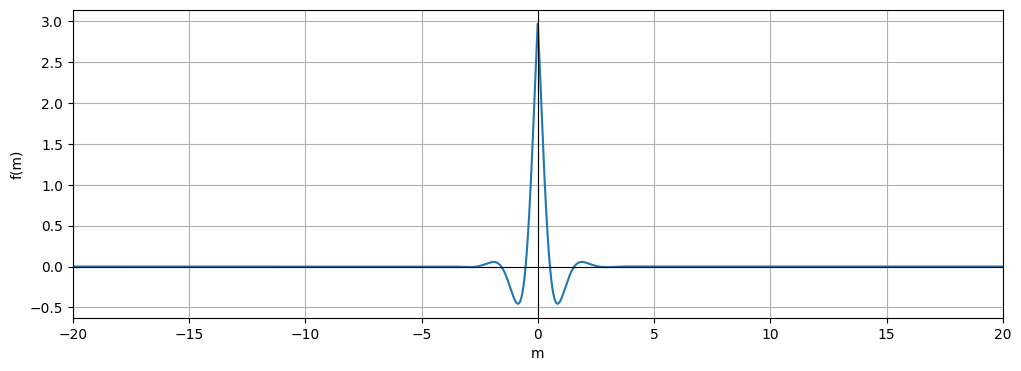

In [109]:
f5 = 3*np.exp(-2*np.abs(m))*np.cos(3*m)

plt.figure(figsize=(12,4))
plt.plot(m, f5)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlim([-20, 20])
plt.xlabel("m")
plt.ylabel("f(m)")
plt.xlabel("m")
plt.grid(True)
plt.show()

#### f) 

$
f_6(m)=3e^{-2|m|}\sin(3m), \qquad \text{para } m \in \mathbb{Z}
$

$f_6(m) is similar to f_5(m), but a product of an odd with an even function instead, which results in an odd function. 

Therefore, **$f_6(m)$ cannot be an Autocorrelation Function**

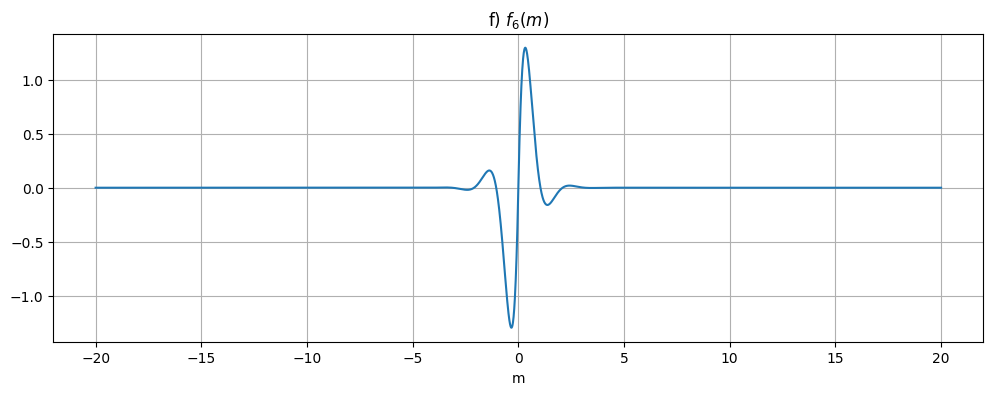

In [110]:
f6 = 3*np.exp(-2*np.abs(m))*np.sin(3*m)

plt.figure(figsize=(12,4))
plt.plot(m, f6)
plt.title("f) $f_6(m)$")
plt.xlabel("m")
plt.grid(True)
plt.show()

#### g)

$
f_7(m)=
\begin{cases}
\dfrac{\sin m}{m}, & \text{for } m \neq 0 \\
1, & \text{for } m = 0
\end{cases}
$

This is a sync function, where $f_7(0)=1$ by L'Hôpital. It easy to show that $\frac{sin(-m)}{-m} = \frac{sin(m)}{m}$ and to note that for every value of m its magnitude will decrease around the origin. 

Therefore, **$f_7(m)$ can be an Autocorrelation Function**

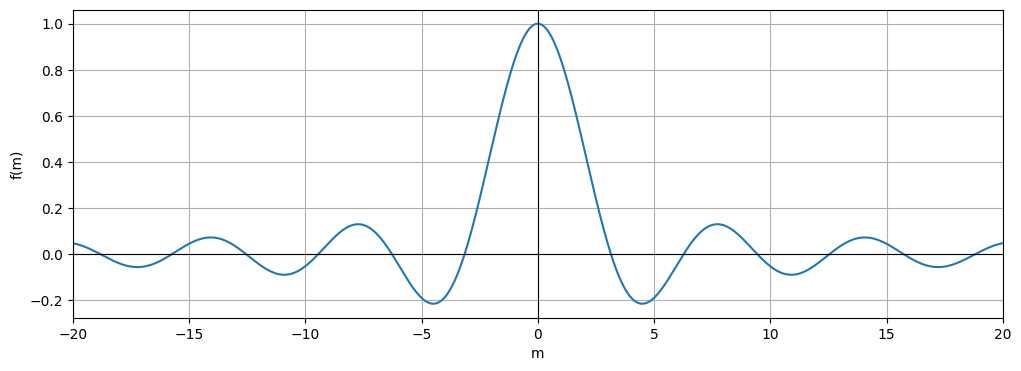

In [111]:
f7 = np.where(m != 0, np.sin(m)/m, 1)

plt.figure(figsize=(12,4))
plt.plot(m, f7)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlim([-20, 20])
plt.xlabel("m")
plt.ylabel("f(m)")
plt.xlabel("m")
plt.grid(True)
plt.show()

### 6 – For each probability density function (PDF) below, determine the expected value E[X] of the corresponding random variable X and also its variance Var(X).

#### a)

$
p_1(x)=
\frac{1}{5\sqrt{2\pi}}
\exp\left(
-\frac{(x-3)^2}{50}
\right)
$

Comparing with the normal distribution:

$
p(x)=
\frac{1}{\sigma_x\sqrt{2\pi}}
\exp\left(
-\frac{(x-\mu_x)^2}{2\sigma_x^2}
\right)
$

We have that $\mu_x=3$, and $\sigma_x=5$, and therefore $E[X]=3$, and $\mathrm{Var}(X)=25$.

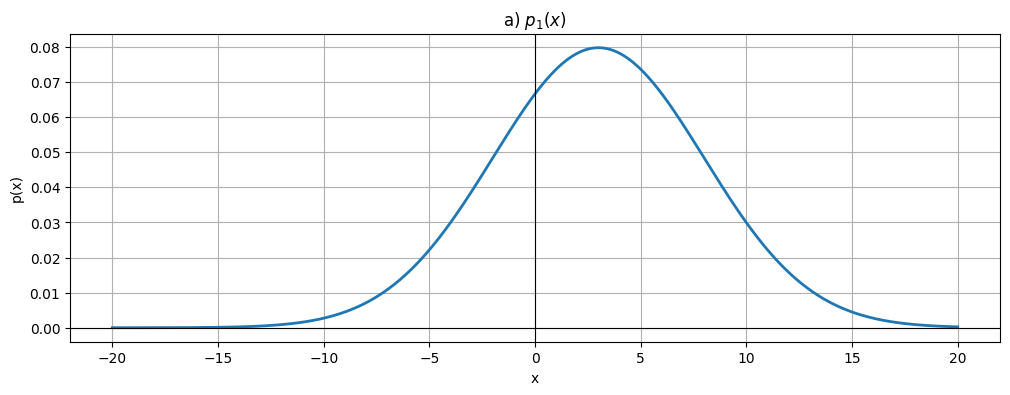

In [112]:
# -------- Gaussian --------

x = m

p1 = (1/(5*np.sqrt(2*np.pi))) * np.exp(-((x-3)**2)/50)

plt.figure(figsize=(12,4))
plt.plot(x, p1, linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(r"a) $p_1(x)$")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.grid(True)
plt.show()

#### b)

$
p_2(x)=
\begin{cases}
\dfrac16, & |x|\le3 \\
0, & |x|>3
\end{cases}
$

For the Expected Value:

$E[X] = \int_{-\infty}^{\infty}x\,p(x)\,dx = \frac16\int_{-3}^{3}x\,dx = \frac16\left[\frac{x^2}{2}\right]_{-3}^{3} = \frac16\left(\frac92-\frac92\right)$

$\rightarrow E[X]=0$

And for the Variance:

$\mathrm{Var}(X)=E[X^2]-\mu_x^2$

Once $\mu_x=0$, we have that:

$\mathrm{Var}(X)=E[X^2] = \int_{-\infty}^{\infty}x^2p(x)\,dx = \frac16\int_{-3}^{3}x^2dx = \frac16\left[\frac{x^3}{3}\right]_{-3}^{3} = \frac16\left(\frac{27}{3}-\frac{-27}{3}\right) = \frac16(9+9) = \frac{18}{6}$

$\rightarrow \mathrm{Var}(X)=3$

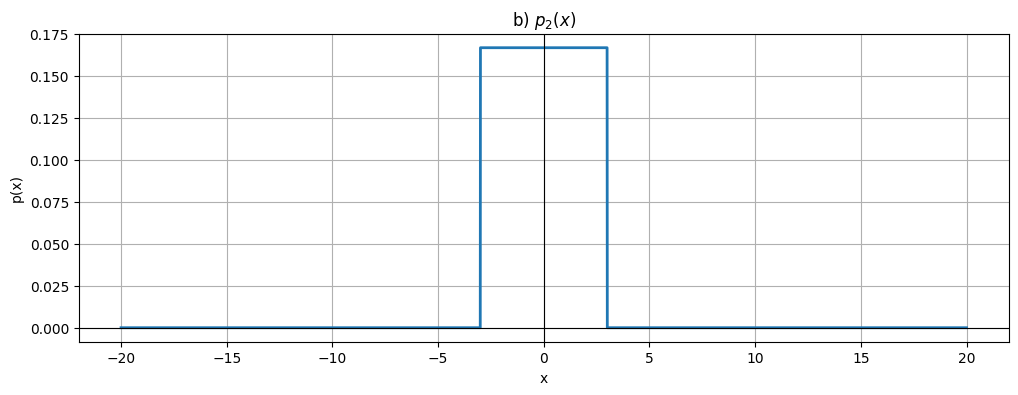

In [113]:

p2 = np.where(np.abs(x) <= 3, 1/6, 0)

plt.figure(figsize=(12,4))
plt.plot(x, p2, linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(r"b) $p_2(x)$")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.grid(True)
plt.show()